# Handcraft allocation + backtest — current config walkthrough

This notebook lets you **step through** the core logic of your live strategy:

1. **Step 0 — Data snapshot.** Ensures the parquet price store (`/tmp/parquet`) is populated. If empty (e.g. after a reboot), it restores it from the repo CSV stores in `data/futures/`.
2. **Step 1 — Load your live config.** Execs the *config-building prefix* of `signals.py` (the same seam the sleeve scripts use), so the notebook always reflects your real config — 28 rules, frozen scalars, frozen handcraft weights, the universe, etc.
3. **Step 2 — Handcraft_shrunk allocation, visualised.** Reproduces `freeze_handcraft_weights.py` step by step: weekly returns → correlation → 50% shrinkage → **dendrogram** of the hierarchy → `handcraft_optimisation` (equal-risk down the tree) → 5% cap → **weight bar chart by asset class**, and checks it against the frozen weights baked into `signals.py`.
4. **Step 3+4 — Build the System and run the backtest** on the snapshot, showing P&L stats, equity curve / drawdown, and per-asset-class Sharpe.

**Source of truth:** `signals.py` (config) and `freeze_handcraft_weights.py` (weights). This notebook *reuses* them rather than re-implementing, so it can't silently drift.

> **Kernel:** select the `pst-env` interpreter (`/Users/kunal.taneja/pysystemtrade/pst-env/bin/python`).

In [38]:
import os, sys, glob, contextlib, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT = "/Users/kunal.taneja/pysystemtrade"
os.chdir(PROJECT)
if PROJECT not in sys.path:
    sys.path.insert(0, PROJECT)

PARQUET_STORE = "/tmp/parquet"   # parquet_store from private/private_config.yaml
ADJ_DIR = f"{PARQUET_STORE}/futures_adjusted_prices"
print("cwd:", os.getcwd())

cwd: /Users/kunal.taneja/pysystemtrade


## Step 0 — Ensure the data snapshot exists

`signals.py` reads adjusted/multiple prices from the parquet store at `/tmp/parquet`. `/tmp` is cleared on reboot, so the cell below repopulates it from the repo's CSV price stores (`data/futures/adjusted_prices_csv` + `multiple_prices_csv`) using the canonical `repocsv_*` loaders.

> **Note:** the repo snapshot covers most of the universe but is missing a couple of newer foreign-exchange instruments (e.g. `TECDAX`) that only ever lived in your local downloads. **Step 0b** (next) rebuilds those from your bc-utils CSVs so the config loads cleanly. It also has an opt-in path to refresh the *whole* bc-utils list for fresher bars.

In [39]:
n_adj = len(glob.glob(f"{ADJ_DIR}/*.parquet"))
print(f"adjusted-price parquet files present: {n_adj}")

if n_adj == 0:
    print("Snapshot empty — restoring from repo CSV stores (this takes a minute)...")
    from sysproduction.data.prices import diagPrices
    from sysdata.csv.csv_adjusted_prices import csvFuturesAdjustedPricesData
    from sysdata.csv.csv_multiple_prices import csvFuturesMultiplePricesData

    diag = diagPrices()
    db_adj = diag.db_futures_adjusted_prices_data
    db_mult = diag.db_futures_multiple_prices_data
    csv_adj = csvFuturesAdjustedPricesData()
    csv_mult = csvFuturesMultiplePricesData()

    mult_codes = set(csv_mult.get_list_of_instruments())
    for code in csv_adj.get_list_of_instruments():
        db_adj.add_adjusted_prices(code, csv_adj.get_adjusted_prices(code), ignore_duplication=True)
        if code in mult_codes:
            db_mult.add_multiple_prices(code, csv_mult.get_multiple_prices(code), ignore_duplication=True)
    print("done.")

print("adjusted parquet files now:", len(glob.glob(f"{ADJ_DIR}/*.parquet")))
print("multiple  parquet files now:", len(glob.glob(f"{PARQUET_STORE}/futures_multiple_prices/*.parquet")))

adjusted-price parquet files present: 255
adjusted parquet files now: 255
multiple  parquet files now: 253


## Step 0c — Data-quality preflight (prevents the backtest crash)

**Why this exists.** The relative-skew rule (`skewrv`) computes a cross-sectional average over **every instrument in each asset class** — via `data.all_instruments_in_asset_class()`, which scans the *whole* snapshot, not just the 59 trading instruments. If any one of those has no usable price after `start_date`, pysystemtrade raises `Exception: No adjusted daily prices for X` and the **entire backtest aborts**. (In the current snapshot the offenders were `ALUMINIUM` and `CNH-CME` — stale junk left over from a partial rebuild, both ending in 2016/2017.)

This cell scans every adjusted-price file and:

- **Quarantines** crash-risk instruments (0 or `< MIN_POST_OBS` daily observations after `start_date`) by moving them to `/tmp/parquet/_quarantine`, so the config and system build cleanly. It first restores anything previously quarantined, so it's safe to re-run.
- **Warns** (keeps) instruments whose data looks corrupt — large calendar gaps, absurd annualised vol, or non-positive back-adjusted prices — so you can see what's polluting the skew average / weights without silently dropping a trading instrument.

`data_quality` (full per-instrument table) is left in the namespace for inspection.

In [ ]:
# === Step 0c: data-quality preflight =========================================
# The relative-skew rule iterates EVERY instrument in an asset class via
# data.all_instruments_in_asset_class() (the full snapshot, not just the 59
# trading instruments). If any of those has no usable price after the start
# date, that rule raises "No adjusted daily prices for X" and aborts the whole
# backtest. This cell scans every adjusted-price file, QUARANTINES the
# crash-risk ones (empty / stale / too-thin) out of the store so the config and
# system load cleanly, and WARNS on instruments whose data looks corrupt
# (calendar gaps, absurd vol, non-positive back-adjusted prices) without
# silently dropping trading instruments.

import shutil, re

START = "2018-01-01"                       # mirrors signals.py config.start_date
_m = re.search(r'config\.start_date\s*=\s*"([0-9-]+)"', open("signals.py").read())
if _m:
    START = _m.group(1)
QUAR_DIR = f"{PARQUET_STORE}/_quarantine"
os.makedirs(QUAR_DIR, exist_ok=True)

MIN_POST_OBS = 60        # need >= this many daily obs after START (else crash/junk)
MAX_GAP_DAYS = 25        # calendar-day gap between obs larger than this is suspect
ABSURD_VOL   = 200.0     # annualised % vol above this => broken roll/back-adjust


def _scan_adjusted(path):
    s = pd.to_numeric(pd.read_parquet(path).squeeze("columns"), errors="coerce").dropna()
    if len(s) == 0:
        return dict(rows=0, post=0, first=None, last=None, max_gap=None,
                    vol=None, min_px=None, med_px=None)
    d = s.resample("1B").last().ffill()
    after = d[d.index >= START].dropna()
    gap = None
    if len(after) > 2:
        g = after.index.to_series().diff().dt.days.dropna()
        gap = int(g.max()) if len(g) else None
    vol = None
    pos = after[after > 0]
    if len(pos) > 6:
        r = pos.pct_change().replace([np.inf, -np.inf], np.nan).dropna()
        if len(r) > 6:
            vol = float(r.std() * np.sqrt(256) * 100)
    return dict(rows=len(s), post=len(after),
                first=s.index.min().date(), last=s.index.max().date(),
                max_gap=gap, vol=vol,
                min_px=float(s.min()), med_px=float(s.median()))


# pull anything previously quarantined back in so the scan starts from a clean state
for _q in glob.glob(f"{QUAR_DIR}/*.parquet"):
    _dest = f"{ADJ_DIR}/{os.path.basename(_q)}"
    if not os.path.exists(_dest):
        shutil.move(_q, _dest)

_records, _quarantined, _warns = [], [], []
for p in sorted(glob.glob(f"{ADJ_DIR}/*.parquet")):
    code = os.path.basename(p)[:-8]
    info = _scan_adjusted(p)
    info["code"] = code
    flags = []
    if info["post"] == 0:
        flags.append("STALE/EMPTY")
    elif info["post"] < MIN_POST_OBS:
        flags.append(f"THIN({info['post']})")
    if info["min_px"] is not None and info["min_px"] <= 0:
        flags.append("NONPOS_ADJ")
    elif (info["med_px"] and info["min_px"] is not None
          and info["min_px"] < 0.01 * abs(info["med_px"])):
        flags.append("NEARZERO_ADJ")
    if info["vol"] is not None and info["vol"] > ABSURD_VOL:
        flags.append(f"ABSURDVOL({info['vol']:.0f}%)")
    if info["max_gap"] is not None and info["max_gap"] > MAX_GAP_DAYS:
        flags.append(f"GAP({info['max_gap']}d)")
    info["flags"] = ", ".join(flags)
    _records.append(info)
    if info["post"] < MIN_POST_OBS:                     # crash-risk => quarantine
        shutil.move(p, f"{QUAR_DIR}/{code}.parquet")
        _quarantined.append(code)
    elif flags:
        _warns.append((code, info["flags"]))

data_quality = pd.DataFrame(_records).set_index("code")
print(f"Scanned {len(data_quality)} adjusted-price files (START={START}).")
print(f"QUARANTINED {len(_quarantined)} crash-risk (empty/stale/thin): {_quarantined}")
print(f"WARN {len(_warns)} kept-but-suspect (gaps / absurd vol / non-positive adj):")
for code, fl in _warns:
    print(f"   {code:16s} {fl}")
print("\nFull table of flagged instruments:")
_flagged = data_quality[data_quality["flags"] != ""]
(_flagged[["post", "first", "last", "max_gap", "vol", "min_px", "med_px", "flags"]]
 .round(2) if len(_flagged) else "— no issues —")

## Step 0d — Roll-integrity test

Checks that each instrument's **continuous (panama-stitched) price** was built from sane rolls, using the `multiple_prices` contract columns:

- **backward** — `PRICE_CONTRACT` rolled to an *earlier* contract (should never happen).
- **wrong_next** — on a roll the new price contract isn't the `FORWARD_CONTRACT` we were already carrying (rolled into an unexpected contract).
- **big_roll_gaps** — price jumped >25% across a roll boundary (stitched across the wrong / an illiquid contract).

`adj_min` (the minimum back-adjusted level) is shown **for information only**. A negative or very low back-adjusted level is **expected and harmless** for instruments with long contango/backwardation histories (energy especially): additive panama stitching shifts the whole series by a constant, so the *level* drifts — but the engine never uses the level. Returns are computed as **`diff(adjusted) / raw_carry_price`** (`rawdata.daily_denominator_price` → the raw front-contract price, always positive), which is invariant to that shift. So a negative `adj_min` is **not** a defect and does not flag the instrument.

Set `ROLL_CHECK_INSTRUMENTS` to a specific list to test just those codes.

In [ ]:
# === Step 0d: roll-integrity test ============================================
# Verifies the continuous (panama-stitched) series was built from sane rolls.
# For each instrument we read multiple-prices and check:
#   backward       PRICE_CONTRACT must never roll to an EARLIER contract
#   wrong_next     on a roll, the new PRICE_CONTRACT should equal the
#                  FORWARD_CONTRACT carried on the row before (we rolled into
#                  the contract we were already holding as 'next')
#   big_roll_gaps  |price ratio - 1| across a roll boundary > ROLL_GAP_WARN
#                  (stitched across the wrong / an illiquid contract)
# adj_min is reported for INFORMATION only. A negative / very low back-adjusted
# level is EXPECTED for long contango/backwardation histories (energy etc.) and
# is NOT a problem: the engine never uses the adjusted level — returns are
# diff(adjusted)/raw_carry_price (level-invariant, carry price always positive,
# see rawdata.daily_denominator_price). So adj_nonpos is NOT a failure condition.
# Set ROLL_CHECK_INSTRUMENTS to a list to test specific codes; None = every
# instrument with multiple-prices in the snapshot.

ROLL_CHECK_INSTRUMENTS = None
MULT_DIR = f"{PARQUET_STORE}/futures_multiple_prices"
ROLL_GAP_WARN = 0.25   # >25% price gap across a roll boundary is suspect


def roll_integrity(code):
    mp = pd.read_parquet(f"{MULT_DIR}/{code}.parquet")
    pc = mp["PRICE_CONTRACT"].astype(str)
    fc = mp["FORWARD_CONTRACT"].astype(str)
    px = pd.to_numeric(mp["PRICE"], errors="coerce")
    roll_mask = pc.ne(pc.shift()) & pc.shift().notna()
    roll_idx = list(np.where(roll_mask.values)[0])
    pcnum = pd.to_numeric(pc, errors="coerce")
    backward = int((pcnum.diff() < 0).sum())
    wrong_next = big_gap = 0
    for i in roll_idx:
        if fc.iloc[i - 1] != pc.iloc[i]:
            wrong_next += 1
        p0, p1 = px.iloc[i - 1], px.iloc[i]
        if p0 and p1 and p0 > 0 and abs(p1 / p0 - 1) > ROLL_GAP_WARN:
            big_gap += 1
    adj = pd.to_numeric(
        pd.read_parquet(f"{ADJ_DIR}/{code}.parquet").squeeze("columns"),
        errors="coerce").dropna()
    return dict(code=code, n_rolls=len(roll_idx), backward=backward,
                wrong_next=wrong_next, big_roll_gaps=big_gap,
                adj_min=round(float(adj.min()), 3) if len(adj) else None)


_roll_codes = (
    [os.path.basename(p)[:-8] for p in sorted(glob.glob(f"{MULT_DIR}/*.parquet"))]
    if ROLL_CHECK_INSTRUMENTS is None else ROLL_CHECK_INSTRUMENTS
)
_roll_rows = []
for _c in _roll_codes:
    if not os.path.exists(f"{MULT_DIR}/{_c}.parquet"):
        _roll_rows.append(dict(code=_c, n_rolls=0, backward=0, wrong_next=0,
                               big_roll_gaps=0, adj_min=None))
        continue
    try:
        _roll_rows.append(roll_integrity(_c))
    except Exception as e:
        print(f"   roll-check error {_c}: {e}")
        _roll_rows.append(dict(code=_c, n_rolls=0, backward=0, wrong_next=0,
                               big_roll_gaps=0, adj_min=None))
roll_report = pd.DataFrame(_roll_rows).set_index("code")
# Genuine roll defects only — NOT adj_nonpos (negative adjusted levels are fine).
roll_problems = roll_report[(roll_report.backward > 0) | (roll_report.wrong_next > 0) |
                            (roll_report.big_roll_gaps > 0)]
print(f"Roll-integrity check on {len(roll_report)} instruments  "
      f"(START={START}, gap warn >{ROLL_GAP_WARN:.0%}).")
if len(roll_problems) == 0:
    print("✓ all rolls forward and next-contract, no big roll-boundary gaps.")
else:
    print(f"⚠ {len(roll_problems)} instruments with genuine roll defects "
          f"(backward / wrong_next / big roll gaps):")
    print(roll_problems.sort_values(["backward", "wrong_next", "big_roll_gaps"],
                                     ascending=False).round(3).to_string())
    _bad_universe = [c for c in roll_problems.index if c in set(globals().get("all_instruments", []))]
    if _bad_universe:
        print(f"\n→ of these, IN THE TRADING UNIVERSE: {_bad_universe}")
# informational: how many carry a negative adjusted level (expected, not an error)
_neg = roll_report[roll_report.adj_min.notna() & (roll_report.adj_min <= 0)]
print(f"\nFYI {len(_neg)} instruments have a negative/low back-adjusted level "
      f"(EXPECTED for contango/backwardation — engine uses diff/carry-price, not the level).")

## Step 0b — Rebuild missing / fresher instruments from bc-utils

Reconstructs adjusted prices from your raw bc-utils hourly CSVs (`~/data/barchart`). By default it only rebuilds **universe instruments missing from the snapshot** (so the config can load). To backtest on the very latest bars, uncomment the bottom block to refresh the whole bc-utils list.

The working recipe (learned the hard way):
- **Stage to a dot-free path** (`/tmp/barchart_data`). pysystemtrade resolves CSV paths as *package* paths, so a home dir like `/Users/kunal.taneja/…` gets mangled (the `.` → `/`) and finds **zero** files.
- **Strip the `+0000` timezone** from the `Time` column — the files mix tz-aware/naive rows and the loader chokes otherwise.
- Hourly load (`FINAL="Latest"`) → derive daily → roll calendar → multiple → adjusted.

> ⚠️ **Mutating + fragile.** Writes to the parquet store and to the repo's `data/futures/roll_calendars_csv/`. Roll-calendar generation is the step that fails per-instrument; those are the cases your bespoke `rebuild_*.py` scripts handle.

In [40]:
prefix = open("signals.py").read().split("# Build system with dynamic optimisation")[0]

# Safety: signals.py's daily_returns() has no missing-file guard, so a single
# universe instrument absent from the snapshot crashes the whole config load.
# Exclude any still-missing instrument by injecting it into `bad_markets`.
_head = prefix.split("def realized_vol")[0]
_g = {}
with contextlib.redirect_stdout(io.StringIO()):
    exec(_head, _g)
_universe = [i for insts in _g["asset_classes"].values() for i in insts]
_still_missing = [i for i in _universe if not os.path.exists(f"{ADJ_DIR}/{i}.parquet")]
if _still_missing:
    print(f"⚠ excluding {len(_still_missing)} still-missing instruments: {_still_missing}")
    prefix = prefix.replace("bad_markets = {", 'bad_markets = {"' + '", "'.join(_still_missing) + '", ', 1)

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    exec(prefix, globals())

print("Config loaded from signals.py")
print(f"  capital            : ${config.notional_trading_capital:,}")
print(f"  vol target         : {config.percentage_vol_target}%")
print(f"  start date         : {config.start_date}")
print(f"  instruments (live) : {len(instruments)}")
print(f"  trading rules      : {len(config.forecast_weights)}")
print(f"  asset classes      : {list(asset_classes.keys())}")
print("\n(prefix stdout suppressed — set SHOW_PREFIX=True to see it)")
SHOW_PREFIX = False
if SHOW_PREFIX:
    print(_buf.getvalue())

Config loaded from signals.py
  capital            : $500,000
  vol target         : 30.0%
  start date         : 2018-01-01
  instruments (live) : 59
  trading rules      : 28
  asset classes      : ['Bonds', 'Grains', 'Energy-Livestock', 'Equity-Risk', 'G10-FX', 'EM-Metal-Crypto']

(prefix stdout suppressed — set SHOW_PREFIX=True to see it)


## Step 1 — Load your live config from `signals.py`

We `exec` everything in `signals.py` *up to* the line `# Build system with dynamic optimisation` — exactly the seam `two_sleeve_spy.py` / `four_sleeve_portfolio.py` use. That defines, in this namespace: `config`, `instruments`, `asset_classes`, `bad_markets`, `all_instruments`, `instrument_vols`, `corr_matrix`, the `FROZEN_*` dicts, the rule lists, and all the pysystemtrade stage imports. The verbose prefix output (per-trade cost filter, fallback weighting) is captured and summarised.

In [41]:
prefix = open("signals.py").read().split("# Build system with dynamic optimisation")[0]

# Keep notebook robust when repo snapshot lacks some instruments.
_head = prefix.split("def realized_vol")[0]
_g = {}
with contextlib.redirect_stdout(io.StringIO()):
    exec(_head, _g)
_universe = [i for insts in _g["asset_classes"].values() for i in insts]
_still_missing = [i for i in _universe if not os.path.exists(f"{ADJ_DIR}/{i}.parquet")]
if _still_missing:
    print(f"⚠ excluding {len(_still_missing)} still-missing instruments: {_still_missing}")
    prefix = prefix.replace("bad_markets = {", 'bad_markets = {"' + '", "'.join(_still_missing) + '", ', 1)

_buf = io.StringIO()
with contextlib.redirect_stdout(_buf):
    exec(prefix, globals())

print("Config loaded from signals.py")
print(f"  capital            : ${config.notional_trading_capital:,}")
print(f"  vol target         : {config.percentage_vol_target}%")
print(f"  start date         : {config.start_date}")
print(f"  instruments (live) : {len(instruments)}")
print(f"  trading rules      : {len(config.forecast_weights)}")
print(f"  asset classes      : {list(asset_classes.keys())}")
print("\n(prefix stdout suppressed — set SHOW_PREFIX=True below to see it)")
SHOW_PREFIX = False
if SHOW_PREFIX:
    print(_buf.getvalue())

Config loaded from signals.py
  capital            : $500,000
  vol target         : 30.0%
  start date         : 2018-01-01
  instruments (live) : 59
  trading rules      : 28
  asset classes      : ['Bonds', 'Grains', 'Energy-Livestock', 'Equity-Risk', 'G10-FX', 'EM-Metal-Crypto']

(prefix stdout suppressed — set SHOW_PREFIX=True below to see it)


## Step 2 — Handcraft_shrunk allocation, step by step

This is the instrument-weight layer. Mechanism (from `freeze_handcraft_weights.py` + `sysquant/.../handcraft.py`):

1. **Weekly returns** from adjusted prices, 2016→ now.
2. **Correlation matrix**, then **shrink 50% toward the average correlation** → stabilises the cluster tree (the "shrunk" in handcraft_shrunk).
3. **Hierarchical tree:** recursively split the universe into the two most-distinct clusters; allocate **equal risk (50/50) to each branch**, scaled by each branch's diversification multiplier; **1/N at the leaves**.
4. `equalise_SR=True` → ignore noisy return estimates (risk-structure only). `equalise_vols=True` → return risk weights directly (each instrument is already vol-scaled downstream).
5. **5% cap** per instrument with redistribution.

### 2a. Build weekly-return estimates + apply 50% correlation shrinkage

In [ ]:
from sysquant.estimators.correlations import correlationEstimate
from sysquant.estimators.mean_estimator import meanEstimates
from sysquant.estimators.stdev_estimator import stdevEstimates
from sysquant.estimators.estimates import Estimates
from sysquant.optimisation.optimisers.handcraft import handcraft_optimisation

MULT_DIR = f"{PARQUET_STORE}/futures_multiple_prices"

def weekly_returns(code):
    # Engine-consistent % returns: adjusted-price DIFFERENCE / raw front-contract
    # (carry) price — NOT pct_change on the adjusted level. The panama-adjusted
    # level can be negative/low for long contango/backwardation histories (energy
    # etc.); that's fine and expected — the level is never used. Diffs are
    # offset-invariant and the carry price is always positive, so returns stay
    # sane. Mirrors rawdata.daily_denominator_price -> raw_carry_data().PRICE.
    adj = pd.to_numeric(pd.read_parquet(f"{ADJ_DIR}/{code}.parquet").squeeze("columns"),
                        errors="coerce").dropna().resample("1B").last().ffill()
    carry = pd.to_numeric(pd.read_parquet(f"{MULT_DIR}/{code}.parquet")["PRICE"],
                          errors="coerce").resample("1B").last().reindex(adj.index).ffill()
    r = (adj.diff() / carry).replace([np.inf, -np.inf], np.nan).dropna()
    return r.resample("W").sum().rename(code)

# universe = all_instruments (bad_markets removed), defined by the signals.py prefix
avail = [i for i in all_instruments if os.path.exists(f"{ADJ_DIR}/{i}.parquet")]
rets = pd.concat([weekly_returns(i) for i in avail], axis=1)
rets = rets[rets.index >= "2016-01-01"].dropna(thresh=int(len(avail) * 0.5)).fillna(0)
cols = list(rets.columns)

corr_df = rets.corr()
vol_series = rets.std() * np.sqrt(52)
mean_series = rets.mean() * 52

estimates = Estimates(
    correlation=correlationEstimate(values=corr_df.values, columns=cols),
    mean=meanEstimates({i: float(mean_series[i]) for i in cols}),
    stdev=stdevEstimates({i: float(vol_series[i]) for i in cols}),
    data_length=len(rets), frequency="W",
)

# Verify the shrinkage actually fires. shrink_correlation_to_average blends
# 50% * (constant avg-corr prior) + 50% * (sample corr), which PRESERVES the
# mean off-diagonal correlation by construction — so comparing means tells you
# nothing. The off-diagonal *dispersion* (std) is what should collapse ~50%.
_off = ~np.eye(len(cols), dtype=bool)
_raw = estimates.correlation.values
_raw_mean, _raw_std = float(_raw[_off].mean()), float(_raw[_off].std())

estimates_shrunk = estimates.shrink_correlation_to_average(0.5)
_shr = estimates_shrunk.correlation.values
_shr_mean, _shr_std = float(_shr[_off].mean()), float(_shr[_off].std())

print(f"{len(cols)} instruments | {len(rets)} weekly obs from {rets.index[0].date()}")
print(f"off-diag corr  mean: {_raw_mean:.3f} -> {_shr_mean:.3f}  (preserved by design)")
print(f"off-diag corr  std : {_raw_std:.3f} -> {_shr_std:.3f}  "
      f"(ratio {_shr_std / _raw_std:.2f} ~ 0.50 confirms 50% shrinkage fired)")

# Sanity: max annualised vol across the universe. With engine-consistent returns
# even the negative-adjusted-level energy names sit in a normal range (~15-40%);
# a 4-digit number here would mean someone reverted to pct_change on the level.
print(f"vol range: {vol_series.min()*100:.0f}% .. {vol_series.max()*100:.0f}%  "
      f"(max = {vol_series.idxmax()})")

### 2b. Dendrogram — the hierarchy handcraft sees

Built on the **shrunk** correlation distance. This is the tree that gets split top-down; each merge height = how distinct two groups are. Leaves coloured by your asset-class labels.

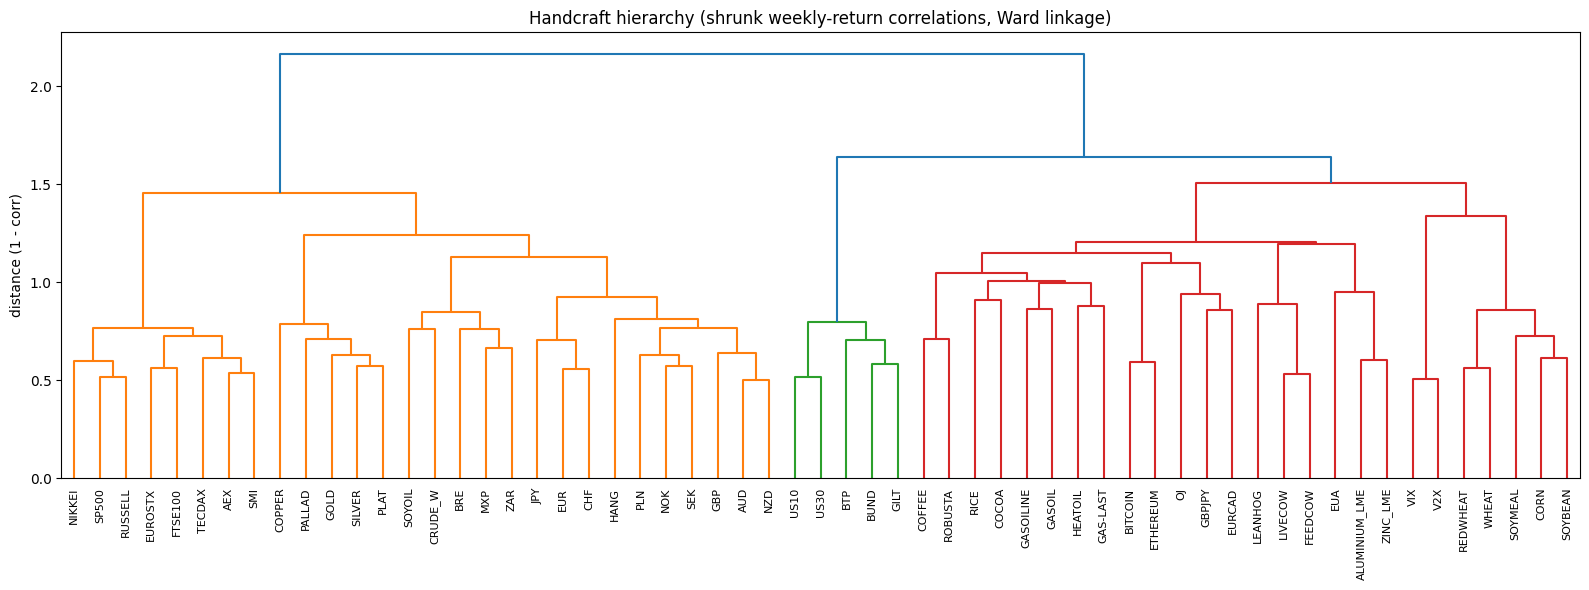

Asset-class labels (for reference):
  Bonds             : US10, US30, BUND, GILT, BTP
  Grains            : REDWHEAT, SOYMEAL, SOYOIL, WHEAT, CORN, SOYBEAN
  Energy-Livestock  : CRUDE_W, GASOILINE, HEATOIL, GAS-LAST, LIVECOW, FEEDCOW, LEANHOG, RICE, GBPJPY, COFFEE, OJ, GASOIL, COCOA, EUA, ROBUSTA
  Equity-Risk       : SP500, RUSSELL, NIKKEI, EUROSTX, FTSE100, VIX, V2X, AEX, HANG, SMI, TECDAX
  G10-FX            : EUR, JPY, GBP, AUD, NZD, CHF, PLN, EURCAD, NOK, SEK
  EM-Metal-Crypto   : MXP, ZAR, BRE, GOLD, SILVER, COPPER, PLAT, PALLAD, BITCOIN, ETHEREUM, ALUMINIUM_LME, ZINC_LME


In [43]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

inst_to_class = {i: c for c, insts in asset_classes.items() for i in insts}
cs = estimates_shrunk.correlation.values
cs = (cs + cs.T) / 2
np.fill_diagonal(cs, 1.0)
dist = squareform(np.clip(1 - cs, 0, 2), checks=False)
Z = linkage(dist, method="ward")

plt.figure(figsize=(16, 6))
dn = dendrogram(Z, labels=cols, leaf_rotation=90, leaf_font_size=8,
                color_threshold=0.7 * Z[:, 2].max())
plt.title("Handcraft hierarchy (shrunk weekly-return correlations, Ward linkage)")
plt.ylabel("distance (1 - corr)")
plt.tight_layout(); plt.show()

print("Asset-class labels (for reference):")
for c, insts in asset_classes.items():
    print(f"  {c:18s}: {', '.join(i for i in insts if i in cols)}")

### 2c. Run handcraft + 5% cap

In [44]:
out = handcraft_optimisation(estimates_shrunk, equalise_SR=True, equalise_vols=True)
raw_weights = dict(out.weights)

def cap_weights(raw, cap_v=0.05):
    w = dict(raw)
    while True:
        over = {k: v for k, v in w.items() if v > cap_v}
        if not over:
            break
        excess = sum(v - cap_v for v in over.values())
        under = {k: v for k, v in w.items() if v <= cap_v}
        if not under:
            break
        ut = sum(under.values())
        for k in over:
            w[k] = cap_v
        for k in under:
            w[k] += excess * (under[k] / ut)
    tot = sum(w.values())
    return {k: v / tot for k, v in w.items()}

computed = cap_weights(raw_weights, 0.05)
wdf = pd.DataFrame({
    "class": {i: inst_to_class.get(i, "?") for i in computed},
    "vol_%": {i: float(vol_series.get(i, np.nan) * 100) for i in computed},
    "weight_%": {i: v * 100 for i, v in computed.items()},
}).sort_values("weight_%", ascending=False)
print("Class totals:")
print((wdf.groupby("class")["weight_%"].sum().sort_values(ascending=False)).round(2))
wdf.round(3).head(50)

Class totals:
class
Energy-Livestock    28.94
EM-Metal-Crypto     19.29
Equity-Risk         17.72
Grains              13.92
G10-FX              12.98
Bonds                7.16
Name: weight_%, dtype: float64


,class,vol_%,weight_%
BRE,EM-Metal-Crypto,16.264,2.479
HEATOIL,Energy-Livestock,1418.641,2.479
JPY,G10-FX,7.752,2.479
GAS-LAST,Energy-Livestock,30.110,2.479
COCOA,Energy-Livestock,89.236,2.479
VIX,Equity-Risk,30.910,2.479
CRUDE_W,Energy-Livestock,21.363,2.479
REDWHEAT,Grains,23.059,2.479
RICE,Energy-Livestock,17.999,2.479
EUA,Energy-Livestock,19.119,2.479


### 2d. Weight bar chart, coloured by asset class

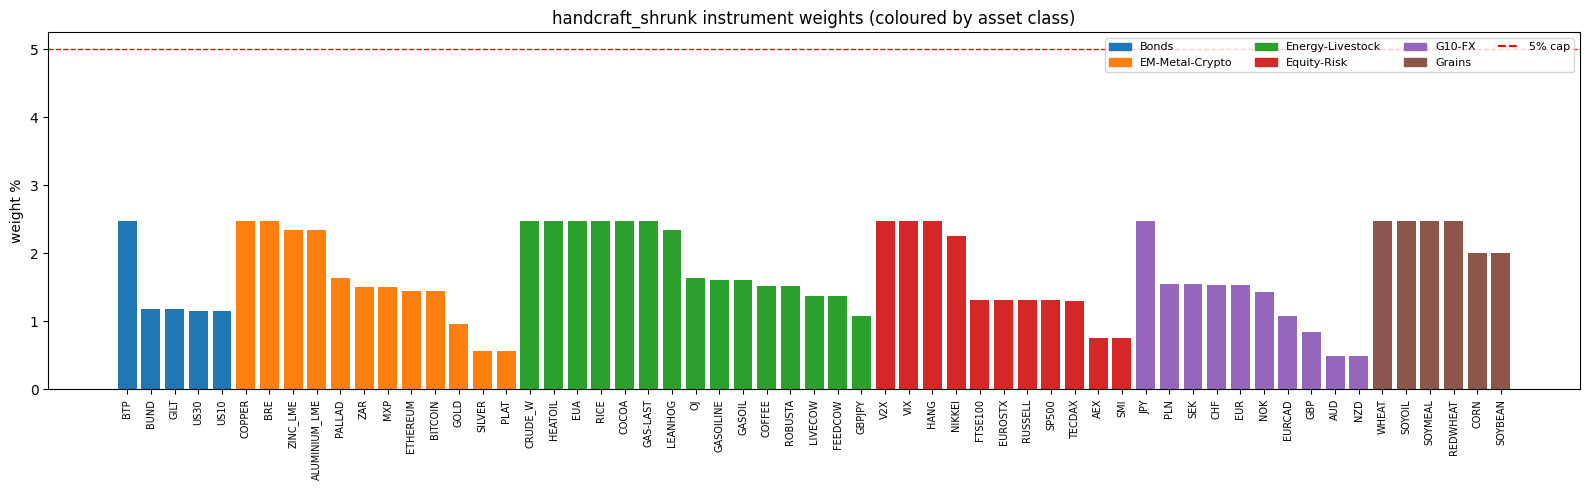

In [45]:
order = sorted(computed, key=lambda i: (inst_to_class.get(i, "?"), -computed[i]))
classes = sorted(set(inst_to_class.get(i, "?") for i in order))
cmap = {c: plt.cm.tab10(k) for k, c in enumerate(classes)}
colors = [cmap[inst_to_class.get(i, "?")] for i in order]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(order)), [computed[i] * 100 for i in order], color=colors)
ax.axhline(5.0, color="red", ls="--", lw=1, label="5% cap")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90, fontsize=7)
ax.set_ylabel("weight %")
ax.set_title("handcraft_shrunk instrument weights (coloured by asset class)")
handles = [plt.Rectangle((0, 0), 1, 1, color=cmap[c]) for c in classes]
ax.legend(handles + [plt.Line2D([0], [0], color="red", ls="--")], classes + ["5% cap"],
          ncol=4, fontsize=8)
plt.tight_layout(); plt.show()

### 2e. Sanity check vs the frozen weights in `signals.py`

`FROZEN_HANDCRAFT_SHRUNK_WEIGHTS` (what the live backtest actually uses) was produced by `freeze_handcraft_weights.py`. If this notebook ran on the same data snapshot, the two should line up closely. Large diffs = the snapshot has moved since the weights were frozen (time to re-run `freeze_handcraft_weights.py`).

In [46]:
frozen = FROZEN_HANDCRAFT_SHRUNK_WEIGHTS
keys = sorted(set(frozen) | set(computed))
cmp = pd.DataFrame({
    "frozen_%": {k: frozen.get(k, 0) * 100 for k in keys},
    "computed_%": {k: computed.get(k, 0) * 100 for k in keys},
})
cmp["diff_pp"] = cmp["computed_%"] - cmp["frozen_%"]
print(f"max |diff| = {cmp['diff_pp'].abs().max():.3f} pp   mean |diff| = {cmp['diff_pp'].abs().mean():.3f} pp")
cmp.reindex(cmp["diff_pp"].abs().sort_values(ascending=False).index).round(3).head(15)

max |diff| = 1.681 pp   mean |diff| = 0.649 pp


,frozen_%,computed_%,diff_pp
BRE,0.798,2.479,1.681
CRUDE_W,0.825,2.479,1.653
SOYOIL,0.825,2.479,1.653
ZINC_LME,0.796,2.341,1.545
ALUMINIUM_LME,0.796,2.341,1.545
EURCAD,2.579,1.082,-1.497
GBPJPY,2.579,1.082,-1.497
US30,2.579,1.156,-1.423
US10,2.579,1.156,-1.423
BUND,2.579,1.184,-1.395


## Step 3 — Build the System (dynamic-optimised, frozen weights)

Identical stage stack to `signals.py`. The frozen weights/scalars are already attached to `config` from Step 1, so this runs your live configuration verbatim.

In [47]:
import logging

# Extra safety: drop any instruments that resolve to empty raw-price series
# in the current parquet snapshot before building the system.
_probe_data = parquetFuturesSimData()
_empty_price_instruments = [
    inst for inst in instruments if len(_probe_data.get_raw_price(inst)) == 0
]
if _empty_price_instruments:
    print(
        f"⚠ excluding {len(_empty_price_instruments)} instruments with empty raw prices: "
        f"{_empty_price_instruments}"
    )
    _existing_bad = set(getattr(config, "bad_markets", []))
    config.bad_markets = sorted(_existing_bad.union(set(_empty_price_instruments)))

system = System(
    [
        accountForOptimisedStage(),
        optimisedPositions(),
        Portfolios(),
        PositionSizing(),
        myFuturesRawData(),
        ForecastCombine(),
        volAttenForecastScaleCap(),
        Rules(),
    ],
    parquetFuturesSimData(),
    config,
)
system.log.logger.setLevel(logging.DEBUG)
print("System built with", len(system.get_instrument_list()), "instruments")

System built with 59 instruments


## Step 4 — Run the backtest

`optimised_portfolio()` runs the full dynamic-optimised backtest. First call is the slow one (computes every rule on every instrument); afterwards results are cached.

In [ ]:
pnl = system.accounts.optimised_portfolio()
stats = pnl.stats()
print(pd.DataFrame(stats[0], columns=["stat", "value"]).to_string(index=False))

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
pnl.curve().plot(ax=ax1, color="steelblue", lw=1.2)
ax1.set_title(f"Current config — cumulative P&L  (Sharpe {pnl.sharpe():.2f})")
ax1.set_ylabel("cumulative P&L ($)"); ax1.grid(alpha=0.3); ax1.axhline(0, color="k", lw=0.5)
dd = pnl.drawdown()
dd.plot(ax=ax2, color="crimson", lw=1.0)
ax2.fill_between(dd.index, dd.values, 0, alpha=0.3, color="crimson")
ax2.set_title("Drawdown"); ax2.set_ylabel("drawdown ($)"); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Per-asset-class Sharpe (optional, slow)

Backtests each instrument's optimised P&L and aggregates by class. Skip if you just want the headline result.

In [ ]:
rows = []
for inst in instruments:
    try:
        s = dict(system.accounts.pandl_for_optimised_instrument(inst).stats()[0])
        rows.append({"instrument": inst, "class": inst_to_class.get(inst, "?"),
                     "sharpe": float(s.get("sharpe", 0) or 0),
                     "ann_mean": float(s.get("ann_mean", 0) or 0)})
    except Exception:
        pass
idf = pd.DataFrame(rows)
by_class = idf.groupby("class").agg(n=("sharpe", "size"), mean_SR=("sharpe", "mean"),
                                    median_SR=("sharpe", "median"), total_ann=("ann_mean", "sum"))
print(by_class.round(3).to_string())
print("\nTop / bottom instruments by Sharpe:")
print(idf.sort_values("sharpe", ascending=False).head(8).round(3).to_string(index=False))
print("...")
print(idf.sort_values("sharpe").head(5).round(3).to_string(index=False))